Make image RGB-to-gray converter using Numba CUDA
* Load an image from file (matplotlib’s imread)
* Flatten image into 1D array of RGB (reshape(pixelCount,
3))
* Implement grayscale using CPU (for range)
* Implement grayscale using GPU
* Save/show the image after each grayscale to validate the
result visually
* Use time.time() to measure speedup

960 * 1280  =  1228800  pixels


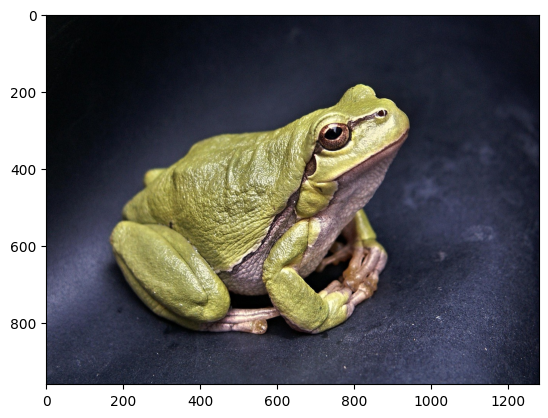

In [1]:
from numba import cuda
from matplotlib import pyplot

img = pyplot.imread("image.jpg")

height = len(img)
width = len(img[0])
pixelCount = height*width
print(height,"*",width," = ",pixelCount," pixels")

pyplot.imshow(img)
pyplot.show()

duration 9.251688241958618


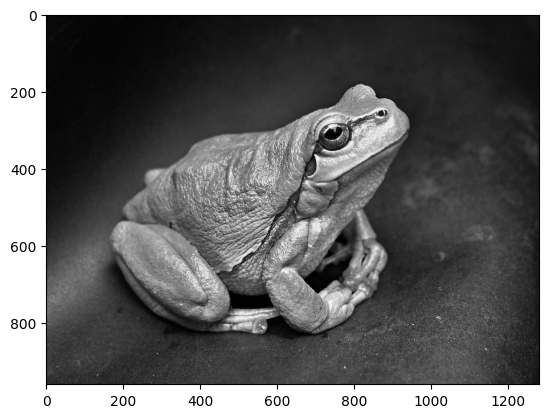

In [2]:
import numpy as np
import time

#initializing the result array /w uint8 dtype (default=float)
gray_array = np.zeros((pixelCount, 3), np.uint8)

def grayscale_CPU(r_img):
  for i in range(pixelCount):
    #making the types real clear as an overflow was causing noise on the final image
    (r,g,b)=np.int16((r_img[i,0], r_img[i,1], r_img[i,2]))
    gray = np.uint8((r+g+b)/3)
    gray_array[i,0] = gray_array[i,1] = gray_array[i,2] = gray
  return gray_array

r_img = img.reshape(pixelCount, 3)

start=time.time()
gray_array = grayscale_CPU(r_img)
stop=time.time()
print("duration",stop-start)

gray_img = gray_array.reshape(height, width, 3)

pyplot.imshow(gray_img)
pyplot.show()

duration 0.3926730155944824


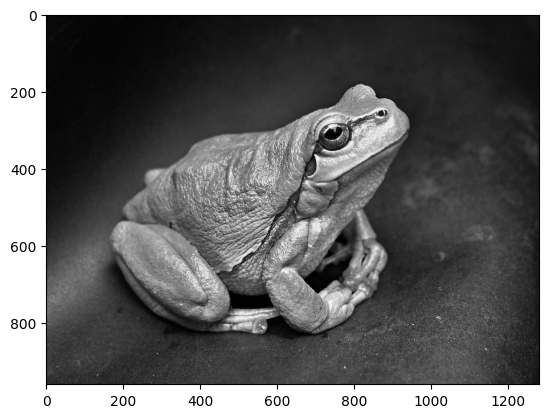

In [3]:
@cuda.jit
def grayscale(src, dst):
  # where are we in the input?
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

devSrc = cuda.to_device(r_img)
devDst = cuda.device_array_like(r_img)
blockSize = 32

#rounding up
gridSize = (pixelCount + blockSize - 1) // blockSize

start=time.time()
#kernel call
grayscale[gridSize, blockSize](devSrc, devDst)
stop=time.time()
print("duration",stop-start)

gray_img = devDst.copy_to_host().reshape(height, width, 3)

pyplot.imshow(gray_img)
pyplot.show()